# Importing daily close data from yahoo finance

In [104]:
import pandas as pd
from matplotlib import pyplot as plt
from rich.console import Console
from rich.table import Table

from stylized_facts import *


In [105]:
df = pd.read_csv('../synth_ts_data_LA/real_dataset_US_1-10B_2019-09-2020-03.csv')
df.set_index('timestamp', inplace=True)

In [106]:
assets, valid_tickers = prepare_assets_array(df)

Final array shape: (720, 138)


## Calculating log returns:

In [107]:
log_returns = calculate_log_returns(assets)
print(f"Assets shape: {assets.shape}")
print(f"Log returns shape: {log_returns.shape}")


Assets shape: (720, 138)
Log returns shape: (720, 137)


### Volatility clustering(Ground Truth)

In [113]:
results = benchmark_volatility_clustering(log_returns, max_lag=50)

In [111]:
summary_data = {
    'Metric': [
        'Overall Clustering Strength (ACF at lag 1)',
        'Number of Assets with Significant Clustering',
        'Percentage of Assets with Significant Clustering',
        'Confidence Interval Threshold',
        'Clustering Strength Std (ACF at lag 1)'
    ],
    'Value': [
        f"{results['clustering_strength']:.4f}",
        results['assets_with_clustering'],
        f"{results['pct_assets_with_clustering']:.1f}%",
        f"±{results['ci_threshold']:.4f}",
        f"±{results['std_acf'][0]:.4f}",
    ]
}
summary_df = pd.DataFrame(summary_data)

from prettytable import PrettyTable

table = PrettyTable()
table.field_names = ["Metric", "Value"]
table.align["Metric"] = "l"
table.align["Value"] = "r"

for _, row in summary_df.iterrows():
    table.add_row([row['Metric'], row['Value']])

print(table)

+--------------------------------------------------+---------+
| Metric                                           |   Value |
+--------------------------------------------------+---------+
| Overall Clustering Strength (ACF at lag 1)       |  0.2894 |
| Number of Assets with Significant Clustering     |     510 |
| Percentage of Assets with Significant Clustering |   70.8% |
| Confidence Interval Threshold                    | ±0.1675 |
| Clustering Strength Std (ACF at lag 1)           | ±0.1813 |
+--------------------------------------------------+---------+


In [36]:
# Lag-wise statistics DataFrame
max_lag = 10
lag_data = {
    'Lag': list(range(1, max_lag + 1)),
    'Mean_ACF': results['mean_acf'],
    'Median_ACF': results['median_acf'],
    'Std_ACF': results['std_acf'],
    'Pct_Positive': results['pct_positive_acf'],
    'Pct_Significant': results['pct_significant_acf']
}
lag_df = pd.DataFrame(lag_data)

lag_df['Mean_ACF'] = lag_df['Mean_ACF'].round(4)
lag_df['Median_ACF'] = lag_df['Median_ACF'].round(4)
lag_df['Std_ACF'] = lag_df['Std_ACF'].round(4)
lag_df['Pct_Positive'] = lag_df['Pct_Positive'].round(1)
lag_df['Pct_Significant'] = lag_df['Pct_Significant'].round(1)

lag_df.head()

,Lag,Mean_ACF,Median_ACF,Std_ACF,Pct_Positive,Pct_Significant
0,1,0.2978,0.2792,0.1828,99.0,70.5
1,2,0.3541,0.3609,0.1868,99.0,81.2
2,3,0.2576,0.2436,0.1538,97.8,68.6
3,4,0.2047,0.1932,0.1338,96.5,55.5
4,5,0.1854,0.1688,0.1210,97.5,50.8


In [37]:
# Full ACF DataFrame for each asset
acf_df = pd.DataFrame(
    results['acf_matrix'],
    index=valid_tickers,
    columns=[f'ACF_Lag_{i+1}' for i in range(max_lag)]
)

# Add summary columns
acf_df['Clustering_Strength'] = acf_df['ACF_Lag_1']
acf_df['Has_Significant_Clustering'] = acf_df['ACF_Lag_1'] > results['ci_threshold']

acf_df.head()

,ACF_Lag_1,ACF_Lag_2,ACF_Lag_3,ACF_Lag_4,ACF_Lag_5,ACF_Lag_6,ACF_Lag_7,ACF_Lag_8,ACF_Lag_9,ACF_Lag_10,Clustering_Strength,Has_Significant_Clustering
NIO.N,0.061280,-0.029670,-0.032360,-0.031684,0.033206,-0.012876,-0.050265,-0.070129,-0.055464,-0.043501,0.061280,False
PRAH.OQ,0.508130,0.455547,0.162906,0.085383,0.050597,-0.003702,0.011063,0.006312,-0.002259,0.037283,0.508130,True
PAG.N,0.158868,0.673875,0.126932,0.202901,0.103285,0.015336,0.071459,0.003602,0.031429,0.010017,0.158868,False
NJR.N,0.685465,0.605850,0.368326,0.184922,0.145001,0.054639,0.067175,0.049265,0.023032,0.048669,0.685465,True
PRAA.OQ,0.009636,0.251298,0.065775,0.178579,0.111811,0.055220,0.146183,0.018004,0.061246,-0.001403,0.009636,False


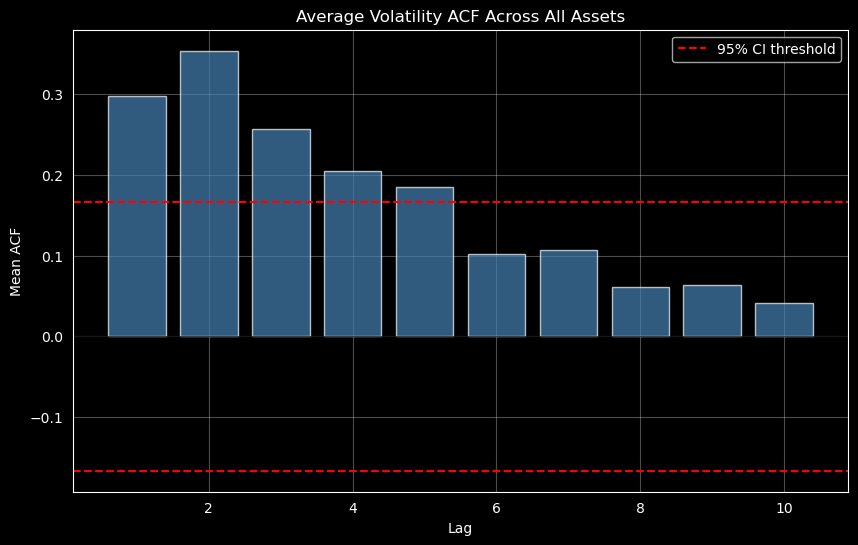

In [38]:
fig, ax1 = plt.subplots(figsize=(10,6))

# Plot 1: Mean ACF with confidence bands
lags = np.arange(1, max_lag + 1)
ax1.bar(lags, results['mean_acf'], alpha=0.7, color='steelblue')
ax1.axhline(y=results['ci_threshold'], color='r', linestyle='--',
            label=f'95% CI threshold')
ax1.axhline(y=-results['ci_threshold'], color='r', linestyle='--')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_xlabel('Lag')
ax1.set_ylabel('Mean ACF')
ax1.set_title('Average Volatility ACF Across All Assets')
ax1.legend()
ax1.grid(True, alpha=0.3)

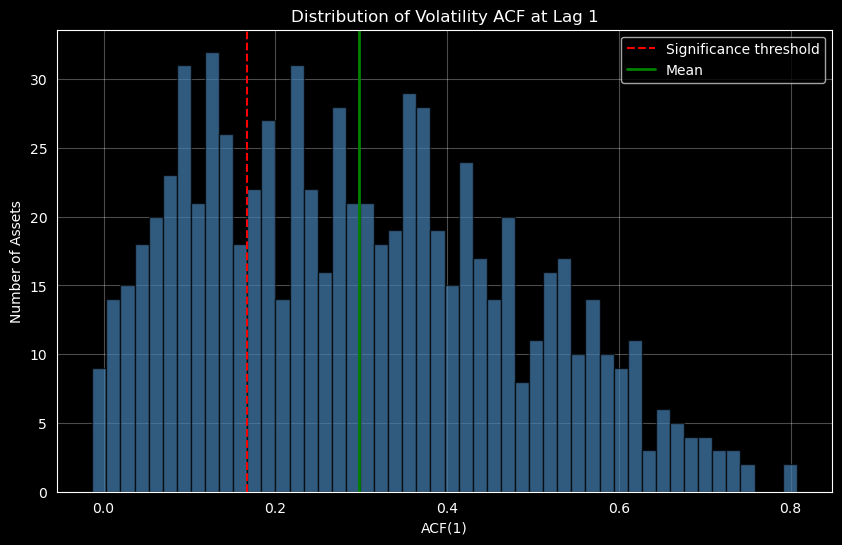

In [39]:
# Plot 2: Distribution of ACF at lag 1
fig, ax2 = plt.subplots(figsize=(10,6))

ax2.hist(results['acf_matrix'][:, 0], bins=50, alpha=0.7,
         color='steelblue', edgecolor='black')
ax2.axvline(x=results['ci_threshold'], color='r', linestyle='--',
            label='Significance threshold')
ax2.axvline(x=results['mean_acf'][0], color='green', linestyle='-',
            linewidth=2, label='Mean')
ax2.set_xlabel('ACF(1)')
ax2.set_ylabel('Number of Assets')
ax2.set_title('Distribution of Volatility ACF at Lag 1')
ax2.legend()
ax2.grid(True, alpha=0.3)



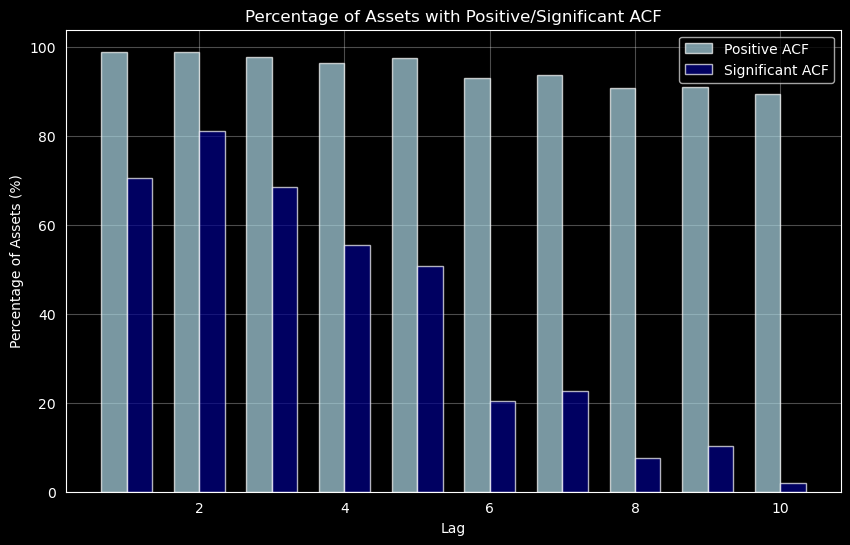

In [40]:
# Plot 3: Percentage of assets with positive/significant ACF
fig, ax3 = plt.subplots(figsize=(10,6))

x = np.arange(1, max_lag + 1)
width = 0.35
ax3.bar(x - width/2, results['pct_positive_acf'], width,
        label='Positive ACF', alpha=0.7, color='lightblue')
ax3.bar(x + width/2, results['pct_significant_acf'], width,
        label='Significant ACF', alpha=0.7, color='darkblue')
ax3.set_xlabel('Lag')
ax3.set_ylabel('Percentage of Assets (%)')
ax3.set_title('Percentage of Assets with Positive/Significant ACF')
ax3.legend()
ax3.grid(True, alpha=0.3)


## Heavy Tails
- remember to convert the feature matrix into a dataframe

In [84]:
# Compute features
feature_matrix, features = compute_heavy_tail_features_per_asset(log_returns)

In [97]:
# Create summary data
summary_data = {
    'Feature': [
        'Alpha+ (right tail)',
        'Alpha- (left tail)',
        'Upper quantile ratio',
        'Lower quantile ratio',
        'Tail exceedance rate'
    ],
    'Mean': [
        f"{np.nanmean(features['alpha_plus']):.4f}",
        f"{np.nanmean(features['alpha_minus']):.4f}",
        f"{np.nanmean(features['upper_quantile_ratio']):.4f}",
        f"{np.nanmean(features['lower_quantile_ratio']):.4f}",
        f"{np.nanmean(features['tail_exceedance_rate']):.4f}"
    ],
    'Std': [
        f"{np.nanstd(features['alpha_plus']):.4f}",
        f"{np.nanstd(features['alpha_minus']):.4f}",
        f"{np.nanstd(features['upper_quantile_ratio']):.4f}",
        f"{np.nanstd(features['lower_quantile_ratio']):.4f}",
        f"{np.nanstd(features['tail_exceedance_rate']):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)

console = Console()

table = Table(title="Heavy-Tail Features Summary", show_lines=True)
table.add_column("Feature", no_wrap=True)
table.add_column("Mean", justify="right")
table.add_column("Std", justify="right")

for _, row in summary_df.iterrows():
    table.add_row(row['Feature'], row['Mean'], row['Std'])

console.print(table)

       Heavy-Tail Features Summary        
┏━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━━┓
┃ Feature              ┃   Mean ┃    Std ┃
┡━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━━┩
│ Alpha+ (right tail)  │ 1.8920 │ 0.6000 │
├──────────────────────┼────────┼────────┤
│ Alpha- (left tail)   │ 1.4799 │ 0.4779 │
├──────────────────────┼────────┼────────┤
│ Upper quantile ratio │ 3.0288 │ 0.6068 │
├──────────────────────┼────────┼────────┤
│ Lower quantile ratio │ 4.5019 │ 1.5087 │
├──────────────────────┼────────┼────────┤
│ Tail exceedance rate │ 0.0495 │ 0.0117 │
└──────────────────────┴────────┴────────┘

In [99]:
feature_matrix.shape

(720, 5)

## Intermittancy

In [166]:
from arch import arch_model

returns_scaled = log_returns[23] * 100

# Fit GARCH model
model = arch_model(returns_scaled, vol='GARCH', p=1, q=1,
                  mean='Zero', rescale=False)
model_fit = model.fit(disp='off', show_warning=False)

In [167]:
def intermittency_acf_signature(cond_vol, short_lag=5, mid_lag=(20, 50)):
    acf_vals = acf(cond_vol, nlags=mid_lag[1], fft=True)

    short = np.mean(acf_vals[1:short_lag])
    mid = np.mean(acf_vals[mid_lag[0]:mid_lag[1]])

    return {
        "short_lag_acf": short,
        "mid_lag_acf": mid,
        "contrast": short - mid
    }


In [168]:
intermittency_acf_signature(model_fit.conditional_volatility)

{'short_lag_acf': np.float64(0.6920020330048655),
 'mid_lag_acf': np.float64(-0.02642921116148307),
 'contrast': np.float64(0.7184312441663486)}

In [178]:
z  = model_fit.std_resid

In [179]:
from statsmodels.stats.diagnostic import acorr_ljungbox

acorr_ljungbox(z, lags=[10, 20], return_df=True)

,lb_stat,lb_pvalue
10,16.109025,0.096554
20,20.075911,0.453190


In [180]:
acorr_ljungbox(z**2, lags=[10, 20], return_df=True)

,lb_stat,lb_pvalue
10,4.271729,0.934257
20,6.388728,0.998260


In [181]:
model_fit.params

omega       0.060971
alpha[1]    0.256687
beta[1]     0.743313
Name: params, dtype: float64

## Absence of linear autocorrelation in returns

In [196]:
acorr_ljungbox(log_returns[719], lags = 20 , return_df=True)

,lb_stat,lb_pvalue
1,2.956033,8.555760e-02
2,19.405042,6.112920e-05
3,19.429688,2.227958e-04
4,27.792124,1.374322e-05
5,38.984438,2.392026e-07
6,45.949979,3.029219e-08
7,53.231115,3.337318e-09
8,54.649768,5.163757e-09
9,61.567178,6.681284e-10
10,61.574193,1.823092e-09


In [194]:
log_returns

array([[ 3.35411807e-02, -1.37892356e-02, -4.47300415e-02, ...,
         1.13789759e-01,  6.82527559e-02,  3.20694736e-02],
       [ 3.73404156e-02,  7.07421914e-02, -2.63380098e-02, ...,
         2.60505007e-02, -1.96710176e-01,  1.38169570e-02],
       [ 1.83148279e-02,  2.52345250e-02,  3.60490715e-03, ...,
        -2.15881497e-02, -2.90681888e-01, -1.24133601e-01],
       ...,
       [ 3.85270051e-02,  2.81020933e-02, -3.62097339e-03, ...,
         1.95322666e-01, -1.18137935e-01,  1.07793597e-01],
       [ 1.20075578e-02,  2.86225101e-02,  1.35637889e-04, ...,
         1.62297322e-01, -3.33097348e-01, -2.31774282e-02],
       [ 2.19321338e-02,  2.58882779e-02, -4.74385183e-03, ...,
         0.00000000e+00, -2.58100385e-01, -3.85364604e-02]])